# Comparing ACTRIS data and CAMS forecast model with Providentia

## Import libraries

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.append('/tljh-home/felles/providentia')

In [3]:
import providentia as prv

## Load configuration file

We are going to load hourly data for nitrogen dioxide mass concentration from the ACTRIS framework and CAMS forecast data for the year June 2023.

In [4]:
provi = prv.Providentia('actris_vre_cams.conf')

In [5]:
provi.print_config()

[ACTRIS-CAMS]
framework = actris/actris
species = nitrogen dioxide mass concentration
resolution = hourly
model = cams_forecast_ensemble (CAMS)
domain = regional
start_date = 20230601
end_date = 20230701
report_type = standard
report_summary = True
report_stations = False
report_filename = PROVIDENTIA_Report
report_title = Report
temporal_colocation = True
observations_data_label = Nitrogen Dioxide Mass Concentration
forecast = day
dl_interpolated = False
dl_mode = both


## Download data

Now we format and download the data from NILU Thredds server (`https://thredds.nilu.no/thredds/catalog/ebas_doi/catalog.html`) into the path defined in `settings/data_paths.json` for local machines.

In [6]:
provi.download()

Starting Providentia download...

----------------------------------------


  - /home/pserrano/data/providentia/obs/nonghost/actris/actris/hourly/sconcno2, source: https://prod-actris-md.nilu.no/metadata/content/nitrogen dioxide mass concentration


    Processing station data: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 40/40

    === ERRORS (2) ===
    ['https://thredds.nilu.no/thredds/dodsC/ebas_doi/9P/Q9/AS/9PQ9-ASUU.nc', 'https://thredds.nilu.no/thredds/dodsC/ebas_doi/JN/NH/XJ/JNNH-XJXT.nc'] (CZ0003R): Selecting station file: could not convert string to float: np.str_('3a').
    ['https://thredds.nilu.no/thredds/dodsC/ebas_doi/M5/GZ/RR/M5GZ-RR35.nc', 'https://thredds.nilu.no/thredds/dodsC/ebas_doi/TT/2B/MK/TT2B-MK9F.nc'] (DE0043G): Selecting station file: could not convert string to float: np.str_('3a').
    === WARNINGS (1) ===
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/KD/JS/W2/KDJS-W2Z8.nc (GB0002R): No data after temporal averaging.



----------------------------------------


dataset = 'cams-europe-air-quality-forecasts'
request = {
'variable' : 'nitrogen_dioxide',
'leadtime_hour' : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96'],
'type' : 'forecast',
'date' : '2023-05-27/2023-05-31',
'model' : 'ensemble',
'level' : '0',
'time' : '00:00',
'data_format' : 'netcdf_zip',
}



Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230527.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230528.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230529.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230530.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230531.nc
dataset = 'cams-europe-air-quality-forecasts'
request = {
'variable' : 'nitrogen_dioxide',
'leadtime_hour' : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', 

Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230601.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230602.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230603.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230604.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230605.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230606.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_20230607.nc
Formatting /home/pserrano/data/providentia/mod_to_interp/cams_forecast_ensemble/regional/hourly/sconcno2/sconcno2_2023

## Interpolate data

In order to see the model data in the observations space, we need to interpolate it. Inside this function we do a nearest-neighbor interpolation.

In [7]:
provi.interpolate()



Variables used for the interpolation:

ghost_version: 1.5
start_date: 202306
end_date: 202307
models:
 - cams_forecast_ensemble-regional-000 (CAMS)
species: ['sconcno2']
network: ['actris/actris']
resolution: ['hourly']
model_resolution: ['hourly']
forecast: ['day']
interp_spinup_timesteps: 0
interp_model_downsampling: mean
interp_model_upsampling: fill
interp_n_neighbours: 4
interp_reverse_vertical_orientation: False
interp_chunk_size: 16
interp_job_array_limit: 100
mod_root: /home/pserrano/data/providentia/mod
ghost_root: /home/pserrano/data/providentia/obs/ghost
nonghost_root: /home/pserrano/data/providentia/obs/nonghost
mod_to_interp_root: /home/pserrano/data/providentia/mod_to_interp
interp_multiprocessing: True

MODEL: CAMS

1 observation files for actris/actris and hourly resolution were found in /home/pserrano/data/providentia/obs/nonghost/actris/actris/hourly/sconcno2.
35 model files for hourly resolution were found in /home/pserrano/data/providentia/mod_to_interp/cams_forec

## Read data

It is time to explore the data, for this we need to first load it in memory.

In [8]:
provi.load()

Updating file tree /home/pserrano/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/pserrano/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - actris/actris|sconcno2
MODELS
 - cams_forecast_ensemble-regional-000-day1 (CAMS-day1)
 - cams_forecast_ensemble-regional-000-day2 (CAMS-day2)
 - cams_forecast_ensemble-regional-000-day3 (CAMS-day3)
 - cams_forecast_ensemble-regional-000-day4 (CAMS-day4)

Resetting data filters to when class was initialised, loading ACTRIS-CAMS subsection filters.
Filtering data


In [9]:
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 594kB
Dimensions:                                                      (
                                                                  data_label: 5,
                                                                  station_actris_actris|sconcno2: 36,
                                                                  time: 720,
                                                                  month: 1)
Coordinates:
  * time                                                         (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconcno2,
                                month
Data variables: (12/27)
    data_labels                                                  (data_label) <U35 700B ...
    actris_actris|sconcno2_data                                  (data_label, station_actris_actris|sconcno2, time) float32 518kB ...
    actris_actris|sconcno2_station_reference                     (station_actris_actris|sconcno2, month) <U7 1kB ...
    actris_actris|sconcno2_longitude                             (station_actris_actris|sconcno2, month) float64 288B ...
    actris_actris|sconcno2_latitude                              (station_actris_actris|sconcno2, month) float64 288B ...
    actris_actris|sconcno2_station_name                          (station_actris_actris|sconcno2, month) <U26 4kB ...
    ...                                                           ...
    actris_actris|sconcno2_principal_investigator_email_address  (station_actris_actris|sconcno2, month) <U31 4kB ...
    actris_actris|sconcno2_contact_name                          (station_actris_actris|sconcno2, month) <U34 5kB ...
    actris_actris|sconcno2_contact_institution                   (station_actris_actris|sconcno2, month) <U58 8kB ...
    actris_actris|sconcno2_contact_email_address                 (station_actris_actris|sconcno2, month) <U31 4kB ...
    actris_actris|sconcno2_doi                                   (station_actris_actris|sconcno2, month) <U34 5kB ...
    actris_actris|sconcno2_actris_national_facility              (station_actris_actris|sconcno2, month) <U5 720B ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

The variable data is stored in `actris_actris|sconcno2_data` by label (in this case only observations), station and time.

In [10]:
data['actris_actris|sconcno2_data']

<xarray.DataArray 'actris_actris|sconcno2_data' (data_label: 5,
                                                 station_actris_actris|sconcno2: 36,
                                                 time: 720)> Size: 518kB
array([[[0.1462    ,        nan, 0.1362    , ..., 0.2118    ,
         0.1975    , 0.195     ],
        [4.        , 4.        , 5.        , ..., 6.5       ,
         7.5       , 4.5       ],
        [4.26      ,        nan, 2.74      , ..., 0.61      ,
         0.91      , 0.91      ],
        ...,
        [1.05      , 0.91      , 0.62      , ..., 1.41      ,
         1.3       , 2.17      ],
        [0.56999856, 0.52      , 0.48      , ..., 0.7800011 ,
         0.82      , 0.83      ],
        [       nan,        nan, 1.125     , ..., 1.794     ,
         1.319     ,        nan]],

       [[0.17848888,        nan, 0.13317448, ..., 0.34406295,
         0.31394953, 0.3159434 ],
        [1.492478  , 1.4093708 , 1.3658483 , ..., 0.761513  ,
         0.94607663, 1.0481728 ],
        [5.322454  ,        nan, 5.3791094 , ..., 1.0274206 ,
         1.0156785 , 1.0678234 ],
...
        [2.45764   , 2.2950847 , 1.8236822 , ..., 6.325103  ,
         6.720374  , 6.0193944 ],
        [1.130201  , 1.1500403 , 1.2556742 , ..., 0.92874104,
         1.0626848 , 1.1315458 ],
        [       nan,        nan, 0.665575  , ..., 0.48363724,
         0.5066479 ,        nan]],

       [[0.19879429,        nan, 0.14794572, ..., 0.30883306,
         0.25737113, 0.3224479 ],
        [1.6061043 , 1.5181689 , 1.1918448 , ..., 0.936376  ,
         1.0496037 , 0.9613306 ],
        [5.907608  ,        nan, 6.002907  , ..., 1.622618  ,
         1.4904823 , 1.4624447 ],
        ...,
        [2.4272728 , 2.141091  , 2.047372  , ..., 5.384884  ,
         5.546697  , 5.696618  ],
        [1.150128  , 1.1360419 , 1.2247785 , ..., 1.3553797 ,
         1.4201723 , 1.4344807 ],
        [       nan,        nan, 0.6293251 , ..., 0.5032368 ,
         0.5625457 ,        nan]]], shape=(5, 36, 720), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2023-06-01 ... 2023-06-30T23:00:00
Dimensions without coordinates: data_label, station_actris_actris|sconcno2
Attributes: (12/26)
    standard_name:                            nitrogen dioxide
    long_name:                                nitrogen dioxide
    units:                                    nmol mol-1
    description:                              Measured value of surface nitro...
    resolution:                               hourly
    resampling_resolution:                    None
    ...                                       ...
    spatial_colocation_station_reference:     True
    spatial_colocation_station_name:          True
    spatial_colocation_longitude_latitude:    True
    spatial_colocation_measurement_altitude:  True
    spatial_colocation_validation:            True
    spatial_colocation_validation_tolerance:  10000.0

While the station information is stored in different variables by month, such as `actris_actris|sconcno2_station_reference`, `actris_actris|sconcno2_station_name`, `actris_actris|sconcno2_latitude` and `actris_actris|sconcno2_longitude`.

In [11]:
data['actris_actris|sconcno2_station_reference']

<xarray.DataArray 'actris_actris|sconcno2_station_reference' (
                                                              station_actris_actris|sconcno2: 36,
                                                              month: 1)> Size: 1kB
array([['AT0034G'],
       ['BE0001R'],
       ['BE0011R'],
       ['BE0013R'],
       ['BE0032R'],
       ['BE0035R'],
       ['CH0002R'],
       ['CH0003R'],
       ['CH0004R'],
       ['CH0005R'],
       ['CH0053R'],
       ['DE0044R'],
       ['DE0054R'],
       ['FI0009R'],
       ['FI0018R'],
       ['FI0022R'],
       ['FI0050R'],
       ['FI0096G'],
       ['FR0030R'],
       ['GB0013R'],
       ['GB0014R'],
       ['GB0031R'],
       ['GB0033R'],
       ['GB0038R'],
       ['GB0043R'],
       ['GB0045R'],
       ['GB0053R'],
       ['GB1055R'],
       ['MT0001R'],
       ['NL0007R'],
       ['NL0009R'],
       ['NL0010R'],
       ['NL0091R'],
       ['NL0644R'],
       ['PL0005R'],
       ['SI0008R']], dtype='<U7')
Dimensions without coordinates: station_actris_actris|sconcno2, month
Attributes:
    standard_name:  station reference
    long_name:      station reference identifier
    units:          unitless
    description:    reference ID for station.

In [12]:
data['actris_actris|sconcno2_station_name']

<xarray.DataArray 'actris_actris|sconcno2_station_name' (
                                                         station_actris_actris|sconcno2: 36,
                                                         month: 1)> Size: 4kB
array([['Sonnblick'],
       ['Offagne'],
       ['Moerkerke'],
       ['Houtem'],
       ['Eupen'],
       ['Vezin'],
       ['Payerne'],
       ['Tänikon'],
       ['Chaumont'],
       ['Rigi'],
       ['Beromünster'],
       ['Melpitz'],
       ['Zugspitze-Schneefernerhaus'],
       ['Utö'],
       ['Virolahti III'],
       ['Oulanka'],
       ['Hyytiälä'],
       ['Pallas (Sammaltunturi)'],
       ['Puy De Dome'],
       ['Yarner Wood'],
       ['High Muffles'],
       ['Aston Hill'],
       ['Bush'],
       ['Lullington Heath'],
       ['Narberth'],
       ['Wicken Fen'],
       ['Charlton Mackrell'],
       ['Chilbolton Observatory'],
       ['Giordan Lighthouse'],
       ['Eibergen'],
       ['Kollumerwaard'],
       ['Vredepeel'],
       ['De Zilk'],
       ['Cabauw Wielsekade'],
       ['Diabla Gora'],
       ['Iskrba']], dtype='<U26')
Dimensions without coordinates: station_actris_actris|sconcno2, month
Attributes:
    standard_name:  station name
    long_name:      station name
    units:          unitless
    description:    Name of station where the measurement was conducted.

In [13]:
data['actris_actris|sconcno2_latitude']

<xarray.DataArray 'actris_actris|sconcno2_latitude' (
                                                     station_actris_actris|sconcno2: 36,
                                                     month: 1)> Size: 288B
array([[47.05407   ],
       [49.877778  ],
       [51.25457   ],
       [51.01628   ],
       [50.629421  ],
       [50.503333  ],
       [46.813056  ],
       [47.479722  ],
       [47.049722  ],
       [47.0674167 ],
       [47.18961391],
       [51.525     ],
       [47.4165    ],
       [59.779167  ],
       [60.53002   ],
       [66.320278  ],
       [61.85      ],
       [67.97333333],
       [45.772223  ],
       [50.596389  ],
       [54.334444  ],
       [52.503889  ],
       [55.862281  ],
       [50.792778  ],
       [51.781784  ],
       [52.298333  ],
       [51.05625   ],
       [51.149617  ],
       [36.0722    ],
       [52.083333  ],
       [53.333889  ],
       [51.541111  ],
       [52.3       ],
       [51.974444  ],
       [54.15      ],
       [45.566667  ]])
Dimensions without coordinates: station_actris_actris|sconcno2, month
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          decimal degrees North
    description:    Geodetic latitude of measuring instrument, in decimal deg...
    axis:           Y

In [14]:
data['actris_actris|sconcno2_longitude']

<xarray.DataArray 'actris_actris|sconcno2_longitude' (
                                                      station_actris_actris|sconcno2: 36,
                                                      month: 1)> Size: 288B
array([[12.95794   ],
       [ 5.203611  ],
       [ 3.36254   ],
       [ 2.58232   ],
       [ 6.001019  ],
       [ 4.989444  ],
       [ 6.9444722 ],
       [ 8.904722  ],
       [ 6.979444  ],
       [ 8.4633333 ],
       [ 8.17543368],
       [12.9277    ],
       [10.97964   ],
       [21.377222  ],
       [27.66754   ],
       [29.401667  ],
       [24.283333  ],
       [24.11611111],
       [ 2.964886  ],
       [-3.713056  ],
       [-0.8075    ],
       [-3.033056  ],
       [-3.205782  ],
       [ 0.179444  ],
       [-4.691462  ],
       [ 0.292778  ],
       [-2.68345   ],
       [-1.438228  ],
       [14.2184    ],
       [ 6.566667  ],
       [ 6.277222  ],
       [ 5.853611  ],
       [ 4.5       ],
       [ 4.923611  ],
       [22.066667  ],
       [14.866667  ]])
Dimensions without coordinates: station_actris_actris|sconcno2, month
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          decimal degrees East
    description:    Geodetic longitude of measuring instrument, in decimal de...
    axis:           X

## Save data

Data can be saved as netCDF or Numpy.

### Save to netCDF

In [15]:
provi.save(format='nc')

Data saved to /home/pserrano/providentia/saved_data/PRV_20260119_1638.nc


### Save to Numpy

In [16]:
provi.save(format='np')

Data saved to /home/pserrano/providentia/saved_data/PRV_20260119_1638.npz


## Plot

The statistics that can be plotted are: `Mean`, `Median`, `StdDev`, `Var`, `Min`, `Max`, `NData`, `Data%`, `NStations`, `Exceedances`, `p1`, `p5`, `p10`, `p25`, `p75` , `p90`, `p95`, `p99`, `MDA8`, `MB`, `NMB`, `ME`, `NME`, `MNB`, `MNE`, `MFB`, `MFE`, `RMSE`, `NRMSE`, `COE`, `FAC2`, `IOA`, `r`, `r2` and `UPA`.

### Maps

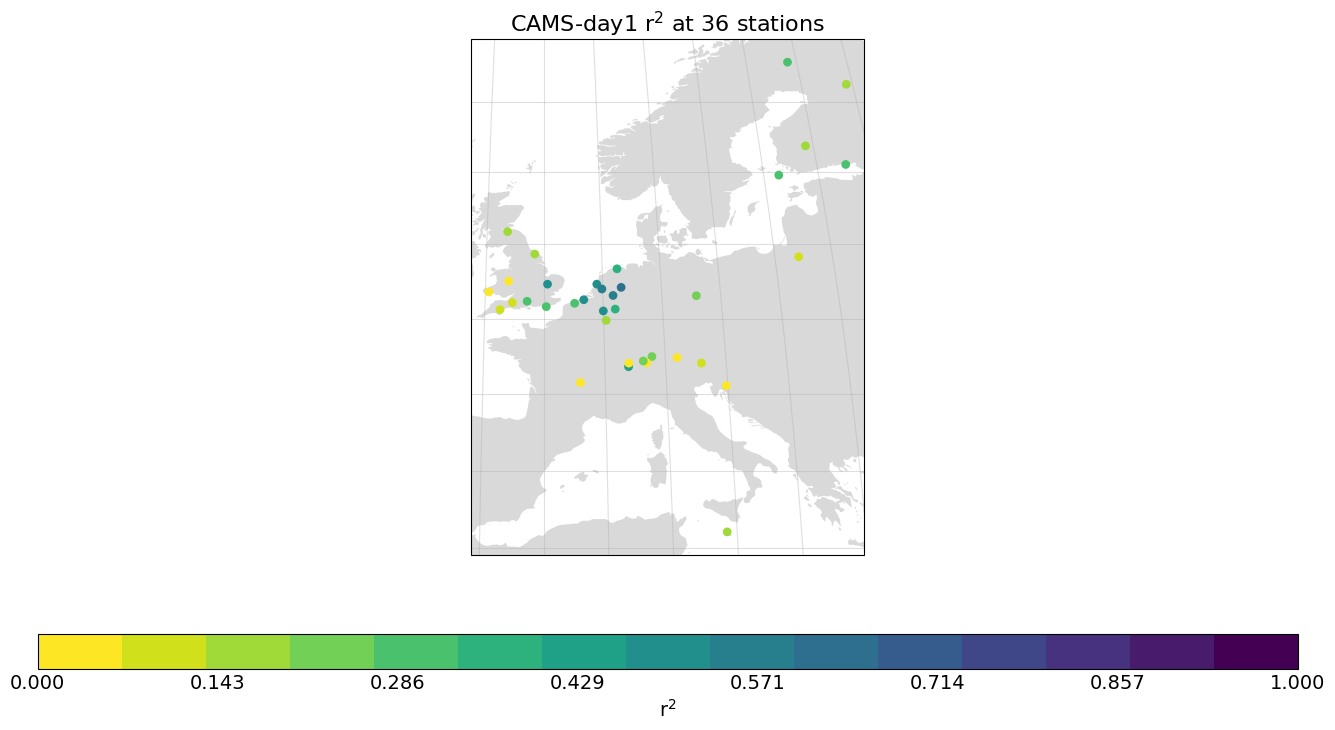

In [17]:
provi.plot('map-r2', labela='Nitrogen Dioxide Mass Concentration', labelb='CAMS-day1')

### Timeseries

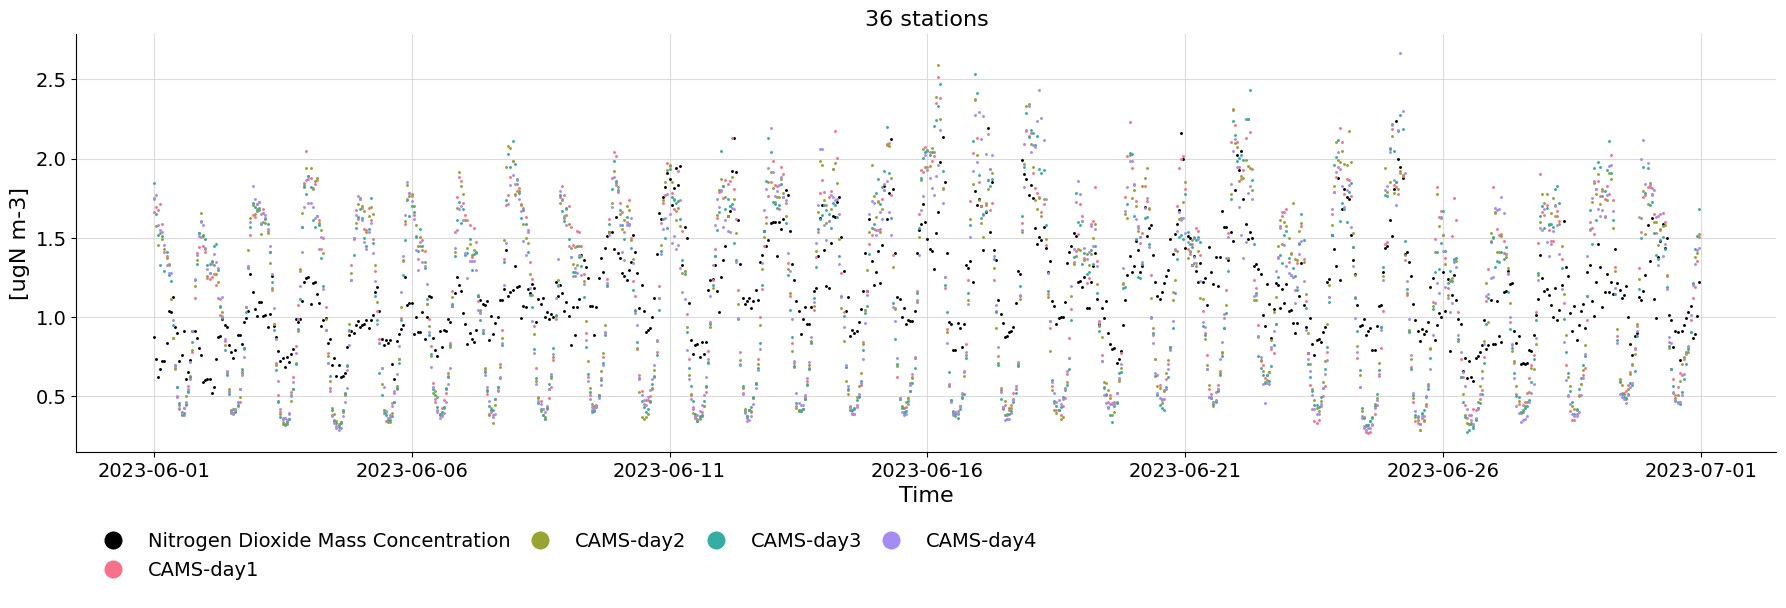

In [18]:
provi.plot('timeseries')

### Periodic plots

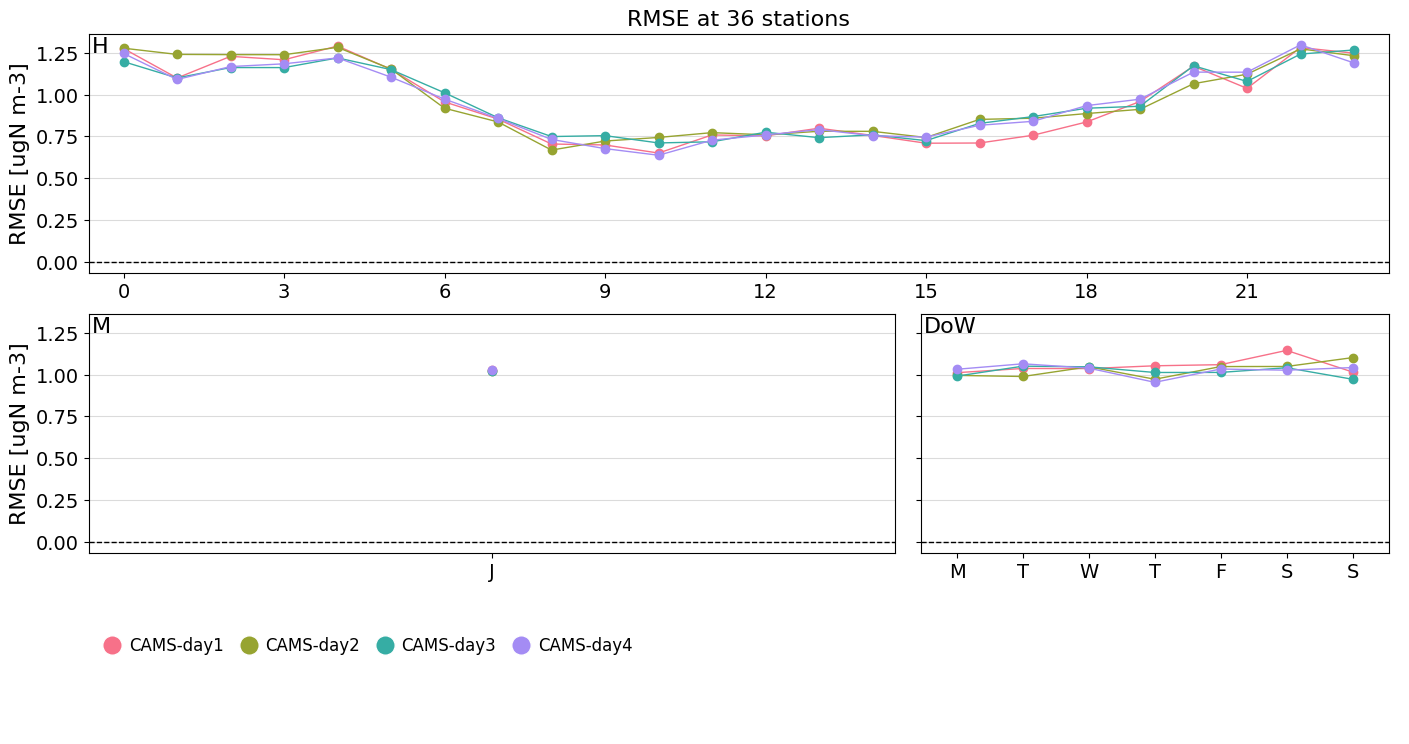

In [19]:
provi.plot('periodic-RMSE')

### Periodic violin plots

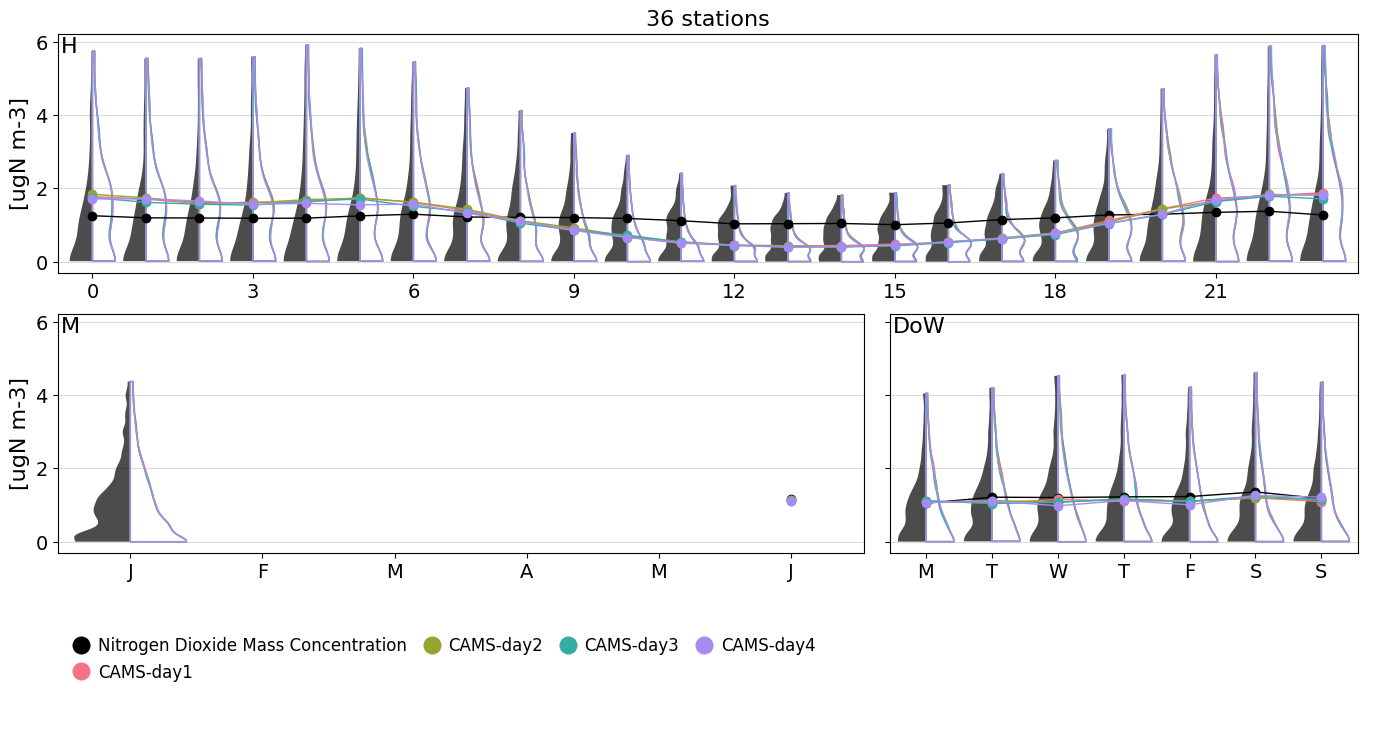

In [20]:
provi.plot('periodic-violin')

### Distribution plots

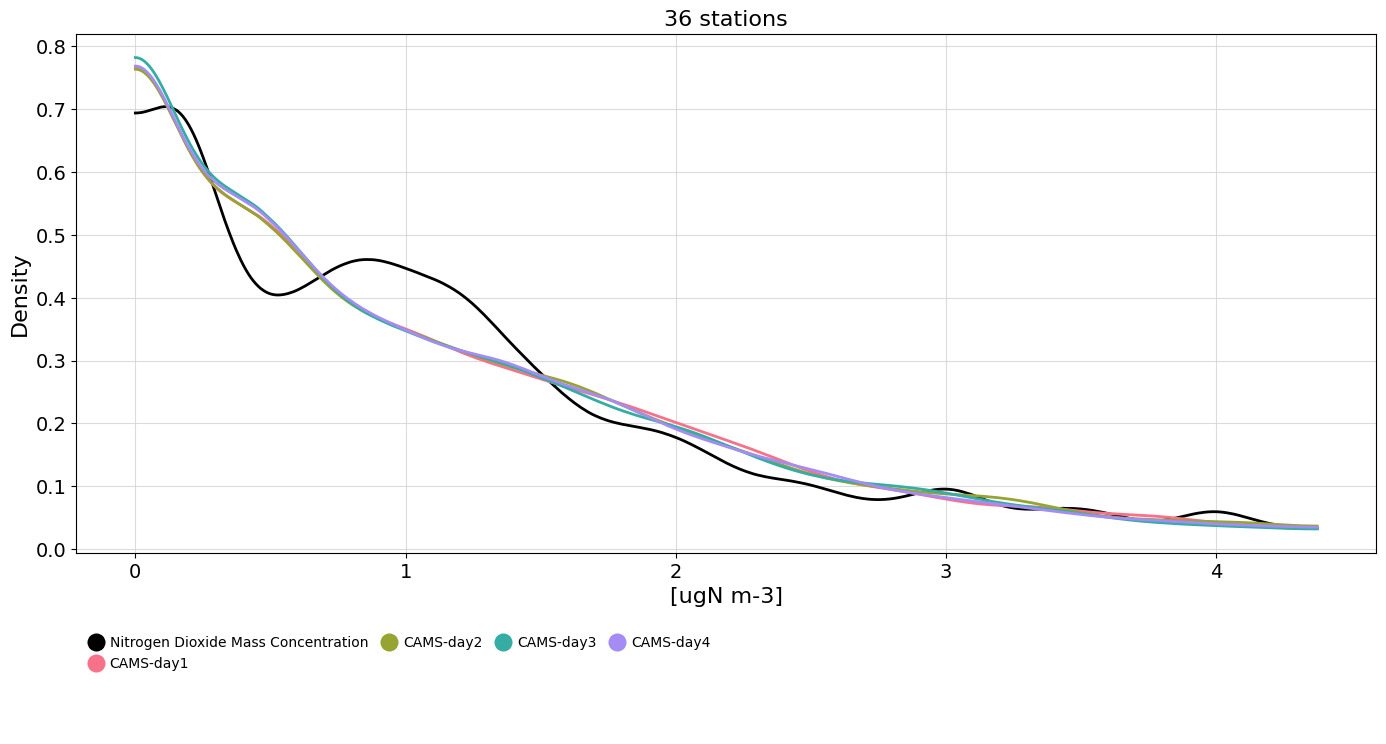

In [21]:
provi.plot('distribution')

### Boxplot

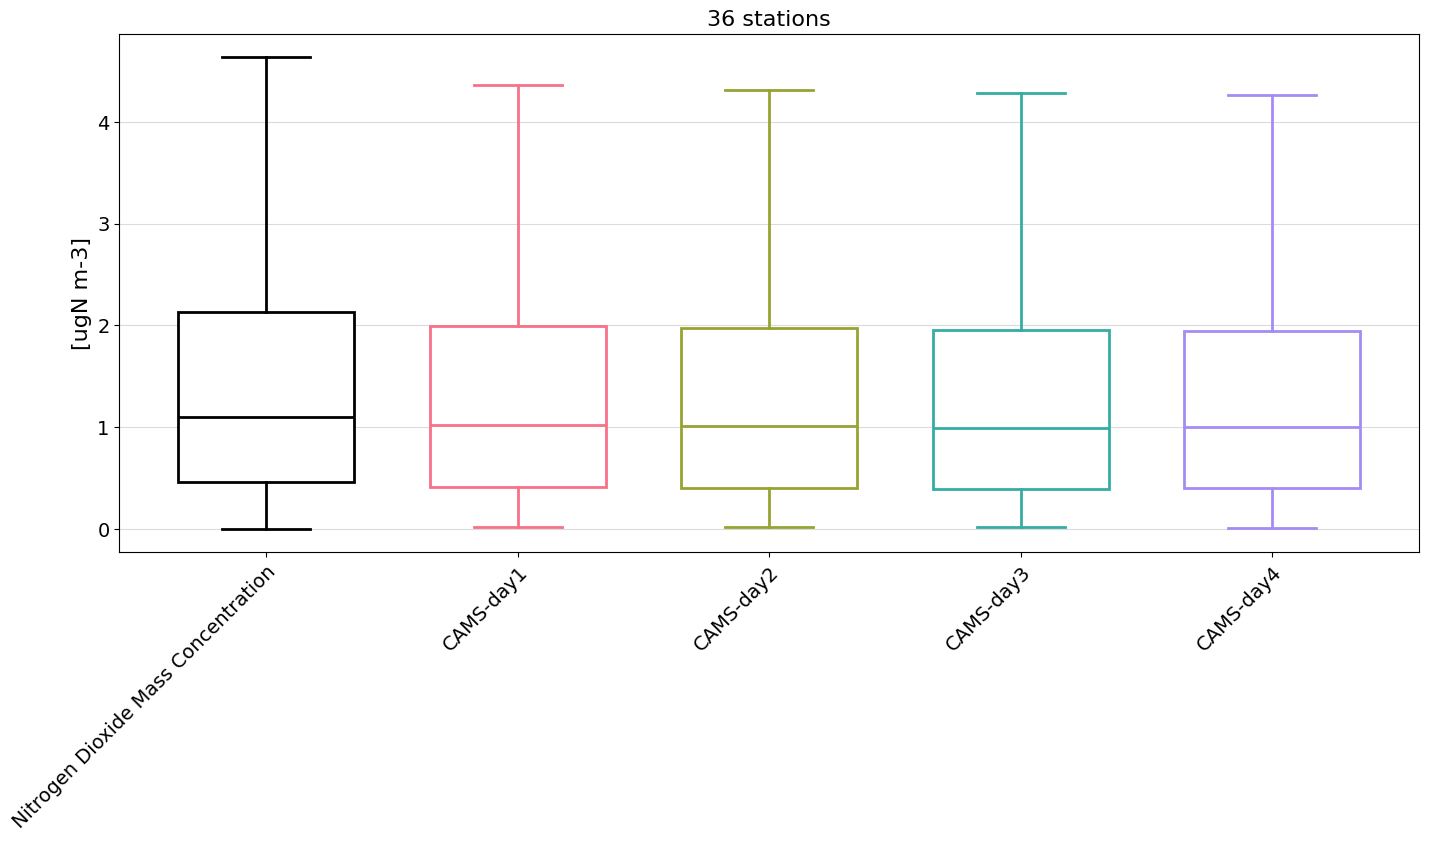

In [22]:
provi.plot('boxplot')

### Scatter

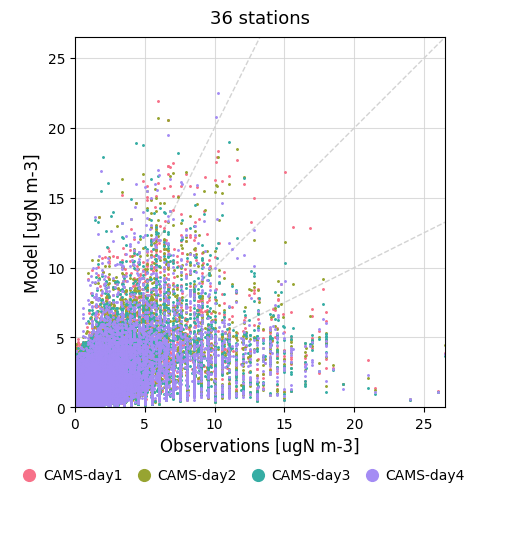

In [23]:
provi.plot('scatter')

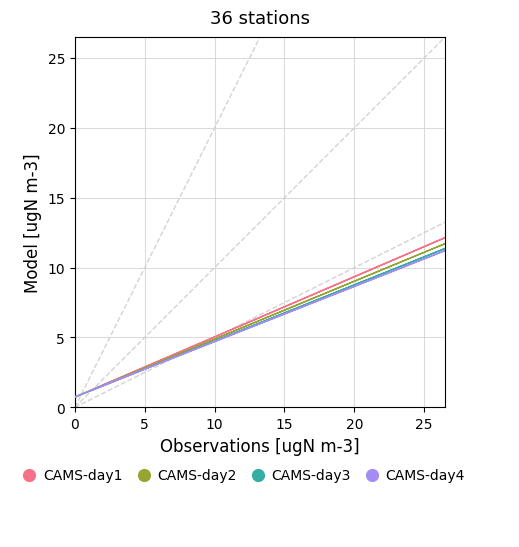

In [24]:
provi.plot('scatter', regression=True, hidedata=True)

### Taylor diagram

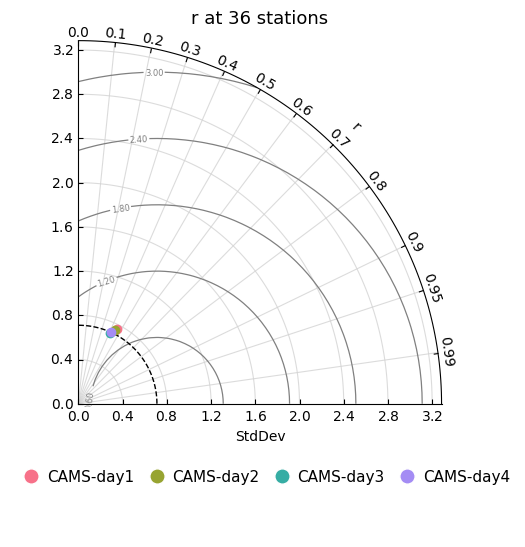

In [25]:
provi.plot('taylor-r')

### Statistic summary

Resetting data filters to when class was initialised, loading ACTRIS-CAMS subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading ACTRIS-CAMS subsection filters.
Filtering data


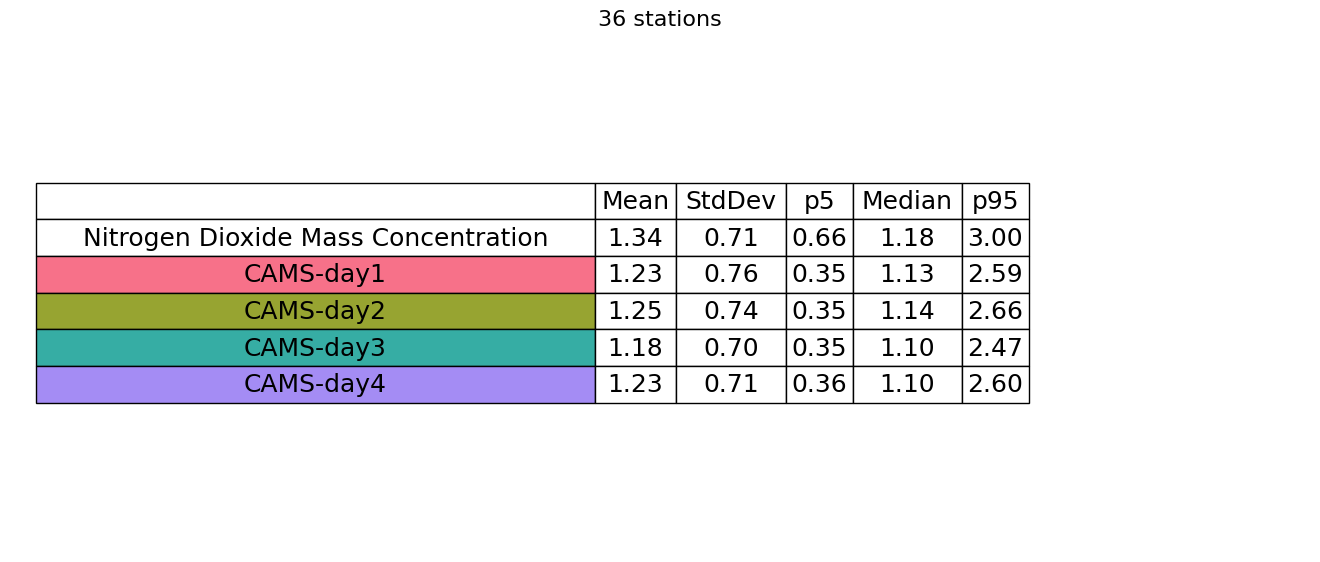

In [26]:
provi.plot('statsummary')

Resetting data filters to when class was initialised, loading ACTRIS-CAMS subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading ACTRIS-CAMS subsection filters.
Filtering data


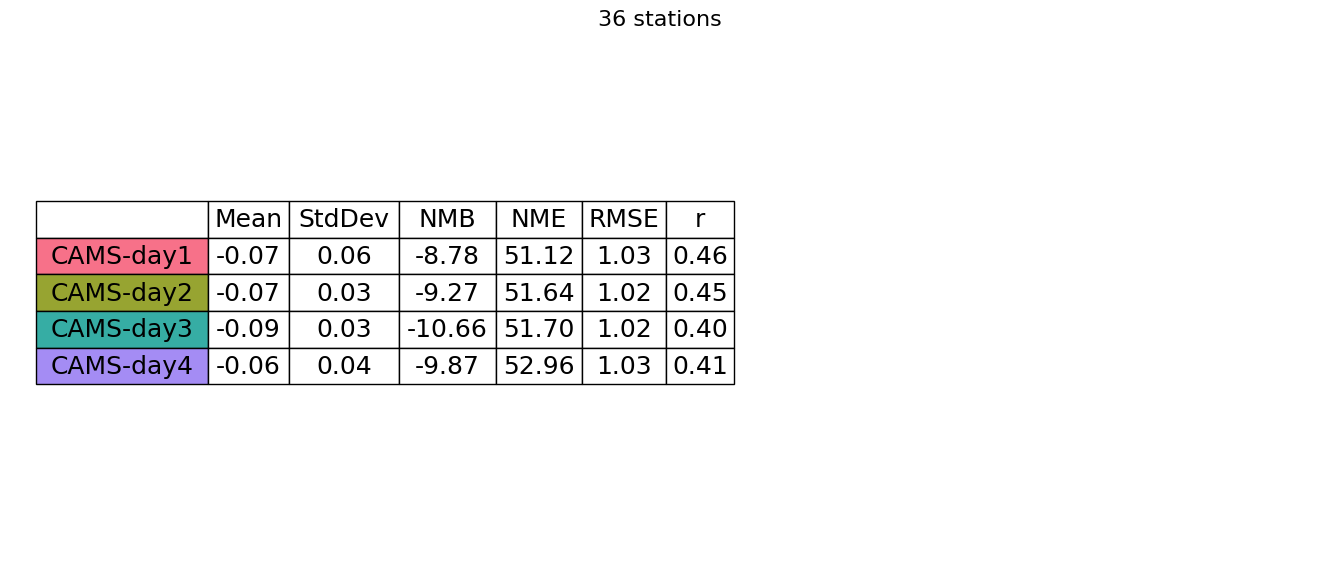

In [27]:
provi.plot('statsummary', bias=True)

### FAIRMODE plots

Data for area_classification is not available and will not be shown in the legend


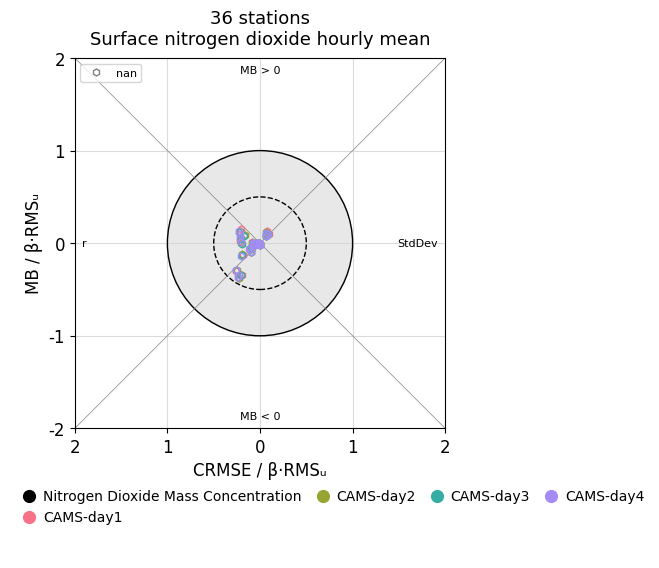

In [28]:
provi.plot('fairmode-target')

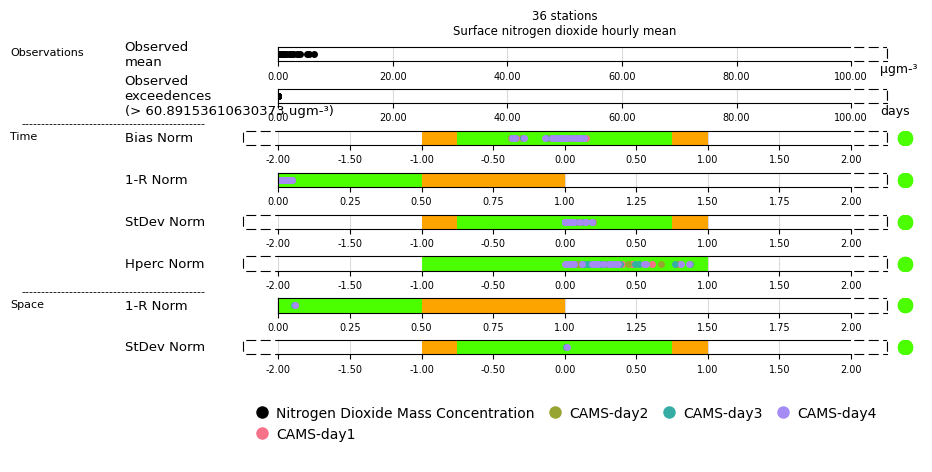

In [29]:
provi.plot('fairmode-statsummary')